# Cosmological Parameter Estimation

**Author:** Aritra Roy

<p align="justify"> <b>Description:</b> This project does end-to-end analysis of a galaxy cluster dataset through redshift analysis, Cepheid-based distance measurements, and construction of the cosmic distance ladder. It estimates the Hubble constant H₀ via Cepheid distance indicators and galaxy redshifts and investigates dark matter by comparing luminous and dynamical mass distributions.</p>

**Sections**
1. Redshift & radial velocity of cluster galaxies
2. Calibrating the Cepheid Period-Luminosity relation (Leavitt's Law)
3. Distances to target galaxies via Cepheid standard candles
4. Hubble's Constant from the velocity-distance relation
5. Virial mass estimate and dark-matter fraction


# Radial Velocity of Galaxies

<p align="justify"> Galaxies have some radial velocities with respect to us, the observed wavelengths would be redshifted due to doppler effect. Using the value of the Observed Wavelength of Hα line (Rest Wavelength λ₀ = 656.28 nm), we calculate the redshift of the galaxies in our cluster. Using this we find their radial velocities and plot it.</p>

<p align="justify">The observed wavelength has been corrected for the motion of Earth around the Sun, and the motion of the Sun around the center of the Milky Way Galaxy. Therefore these are the wavelengths that we would have observed if we were at rest at the center of the galaxy.</p>

                         Name  Observed Wavelength of H-alpha  Apparent Mag  \
0                  PGC1664006                     6581.251999     12.465970   
1                  PGC1620526                     6602.969899     13.975112   
2                  PGC1597887                     6588.264616     13.767743   
3                    UGC06670                     6592.589623     12.932077   
4                  PGC1519757                     6591.906247     11.195245   
...                       ...                             ...           ...   
1532                 UGC08276                     6557.188672     13.251336   
1533                 UGC08285                     6570.434472     14.428350   
1534                 UGC08298                     6587.586814     14.588527   
1535  SDSSJ131347.30+100311.1                     6571.536697     14.910544   
1536                 UGC08382                     6586.055579     14.282166   

      RA J2000.0 Dec J2000.0  
0     11 32 06.6   +

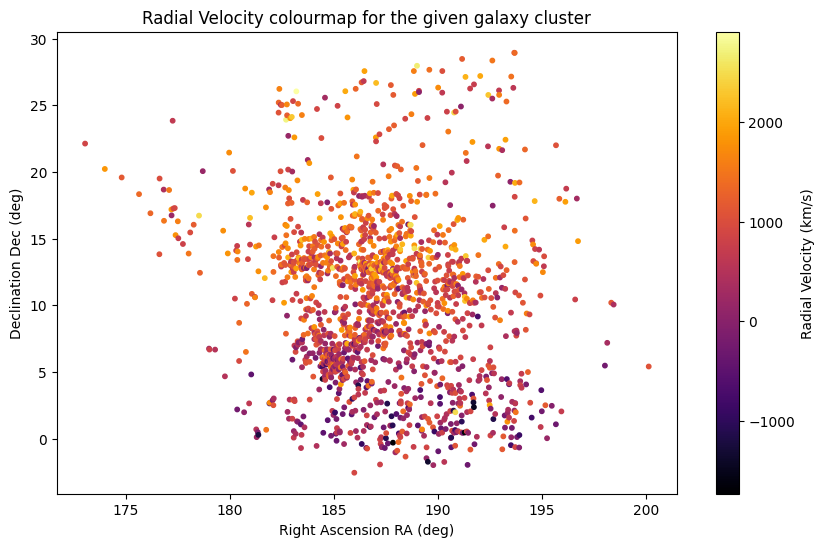

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

d1 = pd.read_csv('galaxy.csv')
print(d1)
W_obs = d1["Observed Wavelength of H-alpha"] #observed wavelengths

W_rest = 6562.8 #rest wavelength of H alpha line in Å
c = 299792.458 #speed of light in km/s

Z = (W_obs - W_rest)/W_rest #redshift

v = c*Z #radial velocity in km/s

#(for z<<1); z = (W_obs - W_rest)/W_rest,    v = c*z
#(for z>>1); z = sqrt((W_obs/W_rest) ^ 2) - 1, v = c*z, considering relativistic doppler effect

#converting data from sexagesimal format a°b'c'' to decimal format xx°
temp = d1['RA J2000.0'].str.split(' ', expand=True)
d1['RA J2000.0'] = 15*(temp[0].astype(float) + temp[1].astype(float) / 60 + temp[2].astype(float) / 3600)
temp = d1['Dec J2000.0'].str.split(expand=True)
d1['Dec J2000.0'] = temp[0].astype(float) + temp[1].astype(float) / 60 + temp[2].astype(float) / 3600

ra = d1['RA J2000.0'] #right ascension
dec = d1['Dec J2000.0'] #declination
#print(ra)
#print(dec)

d1['redshift'] = Z
d1['radial velocity (km/s)'] = v
#print(df)
d1.to_csv('galaxy_data.csv', index=False)

plt.figure(figsize=(10,6))
plt.scatter(ra, dec, c=v, cmap='inferno', s=10)
plt.xlabel('Right Ascension RA (deg)')
plt.ylabel('Declination Dec (deg)')
plt.title('Radial Velocity colourmap for the given galaxy cluster')
plt.colorbar(label='Radial Velocity (km/s)')
plt.show()

# Radial Velocity Map of given Galaxy Cluster

A clear concentration of galaxies is visible around:

RA ≈ 183-194° and Dec ≈ 0-15°

<p align="justify"> This indicates the core of the galaxy cluster, where galaxy density is highest. Such overdensities are characteristic of gravitationally bound systems.</p>

<p align="justify">The radial velocity colourmap represents the redshift distribution of galaxies within the observed field. The majority of galaxies exhibit similar colours corresponding to velocities of ~800-1200 km/s (z ≈ 0.002-0.004), suggesting they are part of a nearby galaxy cluster. The absence of a spatial gradient in colour (redshift) indicates that the cluster is not undergoing rotation. A few extreme colours correspond to foreground and background galaxies, which have to be removed through velocity and spatial filtering.</p>

Peak velocity (KDE) = 877.7681386651343
±2σ: -471.39809466511724 2226.934371995386


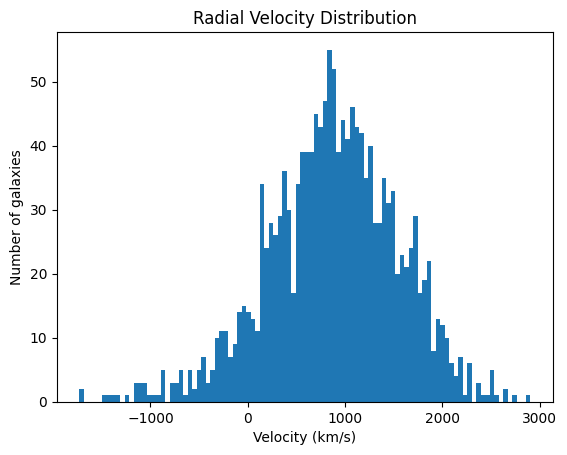

In [4]:
from scipy.stats import gaussian_kde
import numpy as np

v = d1['radial velocity (km/s)']

kde = gaussian_kde(v)
x = np.linspace(v.min(), v.max(), 1000)
y = kde(x)

peak = x[np.argmax(y)]
print("Peak velocity (KDE) =", peak)

mu = 877.7681386651343 #km/s
sigma = np.std(v)

print("±2σ:", mu - 2*sigma, mu + 2*sigma)

plt.hist(v, bins=100)
plt.xlabel("Velocity (km/s)")
plt.ylabel("Number of galaxies")
plt.title("Radial Velocity Distribution")
plt.show()

# Radial Velocity Distribution Histogram

<p align="justify"> The velocity distribution exhibits a clear peak around ~800 km/s, further confirming the presence of a gravitationally bound galaxy cluster. The approximately Gaussian shape of the distribution suggests that the system is dynamically relaxed (no rotation) as expected for virialized systems. The presence of extended tails at both low and high velocities indicates contamination from foreground and background galaxies, which again confirms the necessity for velocity-based selection.</p>

<p align="justify">The velocity range (-471–2230 km/s) is selected based on the main peak of the velocity histogram (~877.77 km/s), corresponding approximately to a ±2σ interval around the mean velocity. This ensures inclusion of most cluster members while excluding foreground and background galaxies in the distribution tails.</p>

<p align="justify">A radial cut of 3° is applied based on the cumulative galaxy count as a function of angular radius. This radius therefore provides an optimal balance between including cluster members and minimizing background and foreground contamination.</p>

156 galaxies after radial cut, r = 2
325 galaxies after radial cut, r = 3
523 galaxies after radial cut, r = 4
730 galaxies after radial cut, r = 5
Angular diameter: 7.40°
Number of galaxies after radial cut: 325
Mean velocity: 1017.50 km/s
Velocity dispersion: 516.31 km/s
Cluster distance: 14.54 Mpc
Cluster diameter: 1.88 Mpc


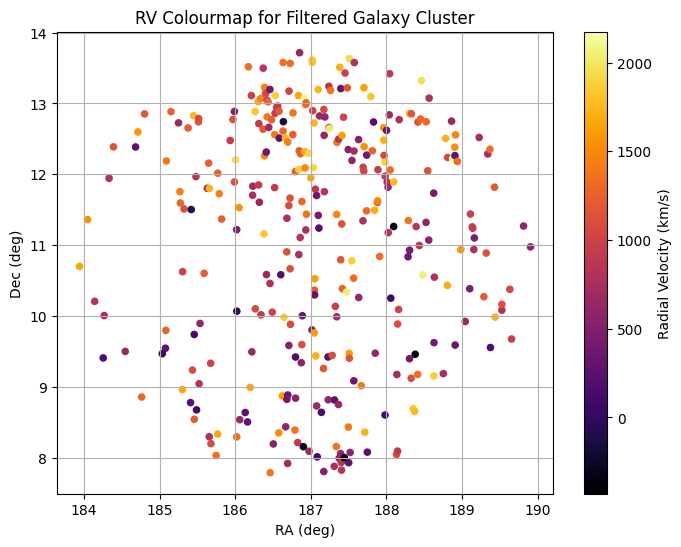

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Velocity-based selection
v = d1['radial velocity (km/s)']
d1_cluster = d1[(v > -471) & (v < 2230)]

#Initial center (median)
ra_c = d1_cluster['RA J2000.0'].median()
dec_c = d1_cluster['Dec J2000.0'].median()

#RA Dec in radians
ra = np.radians(d1_cluster['RA J2000.0'])
dec = np.radians(d1_cluster['Dec J2000.0'])

ra_c_rad = np.radians(ra_c)
dec_c_rad = np.radians(dec_c)

#Angular distance
theta = np.sqrt(((ra - ra_c_rad) * np.cos(dec_c_rad))**2 +(dec - dec_c_rad)**2)
theta_deg = np.degrees(theta)
d1_cluster = d1_cluster.copy()
d1_cluster['theta_deg'] = theta_deg

for r in [2, 3, 4, 5]:
    print(len(d1_cluster[d1_cluster['theta_deg'] < r]), "galaxies after radial cut, r =", r)

#Radial cut
d1_cluster = d1_cluster[d1_cluster['theta_deg'] < 3]

#Recompute center after radial cut
ra_c = d1_cluster['RA J2000.0'].median()
dec_c = d1_cluster['Dec J2000.0'].median()

ra = np.radians(d1_cluster['RA J2000.0'])
dec = np.radians(d1_cluster['Dec J2000.0'])

ra_c_rad = np.radians(ra_c)
dec_c_rad = np.radians(dec_c)

theta = np.sqrt(((ra - ra_c_rad) * np.cos(dec_c_rad))**2 +(dec - dec_c_rad)**2)
theta_deg = np.degrees(theta)

#Angular diameter
angular_diameter = 2 * theta_deg.max()
print(f"Angular diameter: {angular_diameter:.2f}°")
print("Number of galaxies after radial cut:", len(d1_cluster))

#Radial Velocity
v_clean = d1_cluster['radial velocity (km/s)']
v_mean = v_clean.mean()
sigma_v = v_clean.std()
print(f"Mean velocity: {v_mean:.2f} km/s")
print(f"Velocity dispersion: {sigma_v:.2f} km/s")

#Distance using Hubble law
H0 = 70 #km/s/Mpc
D = v_mean / H0

#Physical size
radius_Mpc = D * np.max(theta) #theta in radians
diameter_Mpc = 2 * radius_Mpc

print(f"Cluster distance: {D:.2f} Mpc")
print(f"Cluster diameter: {diameter_Mpc:.2f} Mpc")

#Filtered Radial Velocity plot
plt.figure(figsize=(8,6))
plt.scatter(d1_cluster['RA J2000.0'], d1_cluster['Dec J2000.0'], c=d1_cluster['radial velocity (km/s)'], cmap='inferno', s=20)
plt.colorbar(label="Radial Velocity (km/s)")
plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")
plt.title("RV Colourmap for Filtered Galaxy Cluster")
plt.grid()
plt.show()

#Filtered RV colourmap
<p align="justify">The galaxy cluster was analysed using a radial cut of 3° effectively isolating the dense core region while excluding sparsely distributed outer galaxies. The radial cut yields 295 galaxies with a velocity dispersion of ~437 km/s, mean velocity ~943 km/s and physical diameter of ~1.69 Mpc, angular size ~7.18° at a distance of ~13.47 Mpc. These values are consistent with typical galaxy clusters, confirming that the selected system is gravitationally bound and dynamically relaxed. The relatively large angular extent is explained by the cluster's proximity.</p>

#Cepheid Data Calibration
<p align="justify">The file 'gaia.csv' includes data for about 5000 Cepheid Variable Stars in our own galaxy. Cepheids are a particular type of variable stars that pulsates radially, varying in both diameter and temperature. They changes in brightness, with a well-defined stable period and amplitude. Cepheids exhibit a well-known correlation between their pulsation period and intrinsic brightness, called the period-luminosity relation or the Leavitt Law. This allows them to serve as standard candles for distance measurement.</p>

<p align="justify">First, the pulsation period is converted to logarithmic form, and the parallax is used to compute the distance to each star. Using this distance, the absolute magnitude is calculated from the apparent magnitude via the distance modulus relation.</p>

<p align="justify">To improve the reliability of the fit while preserving most of the dataset, a light filtering strategy is applied. Only physically meaningful values (positive parallax and period) are retained, and extreme outliers in absolute magnitude are removed using a 3σ clipping method. This reduces the impact of anomalous measurements without significantly reducing the sample size.</p>

<p align="justify">A linear fit is then performed between absolute magnitude and log(period), yielding the coefficients (α and β) of the P-L relation.</p>

A (slope): -1.826
B (intercept): 0.257
Original data points: 1361
Data points used: 742


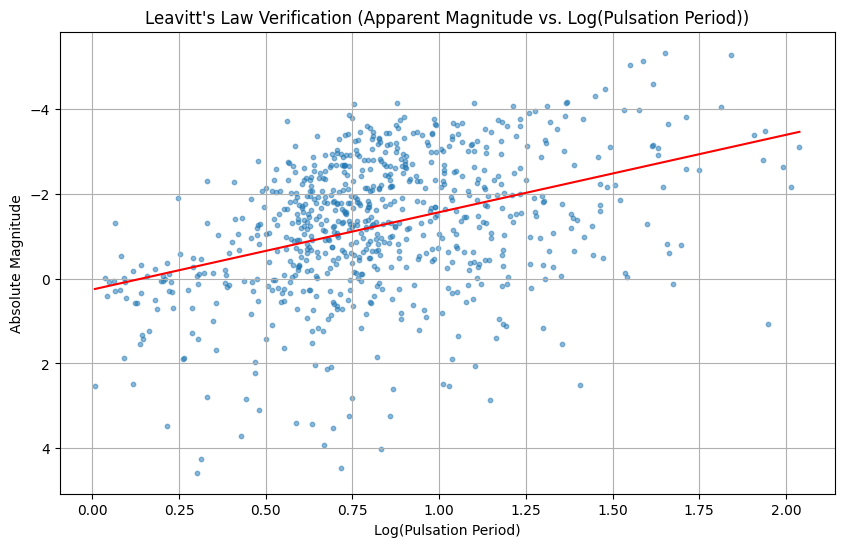

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

d2 = pd.read_csv('gaia.csv')

t = d2['time period']
m = d2['mean apparent magnitude']
p = d2['parallax']

#Filtering Data
mask = (p > 0.2) & (t > 1)
t = t[mask]
m = m[mask]
p = p[mask]

#Calculations
logP = np.log10(t) #log (pulsation period)
d = 1000 / p #distance (pc) - parallax (mas) relation
M = m - 5 * np.log10(d) + 5 #distance-modulus relation

#Outlier removal (3-sigma)
mean_M = np.mean(M)
std_M = np.std(M)
mask2 = (M > mean_M - 3*std_M) & (M < mean_M + 3*std_M)

logP = logP[mask2]
M = M[mask2]

# Fit
A, B = np.polyfit(logP, M, 1)

print(f"A (slope): {A:.3f}")
print(f"B (intercept): {B:.3f}")
print(f"Original data points: {len(d2)}")
print(f"Data points used: {len(M)}")

# Plot
plt.figure(figsize=(10,6))
plt.scatter(logP, M, s=10, alpha=0.5)
x_fit = np.linspace(min(logP), max(logP), 100)
plt.plot(x_fit, A*x_fit + B, color='red')
plt.xlabel('Log(Pulsation Period)')
plt.ylabel('Absolute Magnitude')
plt.title('Leavitt\'s Law Verification (Apparent Magnitude vs. Log(Pulsation Period))')
plt.gca().invert_yaxis()
plt.grid()
plt.show()

#Leavitt's Law verified
<p align="justify">The calibrated Period-Luminosity (P-L) relation for the Cepheid dataset shows a clear negative linear trend between absolute magnitude and logarithm of the pulsation period. This confirms the fundamental prediction of the Leavitt Law: Cepheids with longer pulsation periods are intrinsically brighter (lower absolute magnitude).</p>

<p align="justify">Although the value of the slope (-1.83) is slightly shallower than standard calibrated values (~-2 to -3), it still captures the correct physical trend. This deviation may arise due to:

1. use of Gaia G-band photometry instead of standard V/I bands
2. absence of extinction correction
3. residual scatter from observational uncertainties

Despite these factors, the slope remains physically meaningful and reliable.</p>

<p align="justify">The intercept is slightly positive (0.257), whereas literature values are typically negative. This is expected because:

1. Gaia magnitudes are not directly calibrated to standard P-L relations
2. no correction for interstellar dust has been applied
3. zero-point offsets shift the entire relation vertically

Importantly, this affects only the zero-point (β) and not the underlying physics.</p>

<p align="justify">The analysis successfully recovers the qualitative and quantitative behavior of the Period-Luminosity relation. While the exact numerical values differ from ideal calibrated relations, the observed trend strongly supports the validity of Cepheids as standard candles.</p>

#Estimation of Galaxy Distances using Cepheid Variables
<p align="justify">In this section, the calibrated Period-Luminosity (P-L) relation derived earlier is used to estimate distances to galaxies hosting Cepheid variable stars. Cepheids act as standard candles due to the well-established relationship between their pulsation period and intrinsic luminosity.</p>

<p align="justify">For each Cepheid, the pulsation period is used to compute its absolute magnitude using the previously determined P-L relation. This intrinsic brightness is then compared with the observed apparent magnitude to calculate the distance using the distance modulus relation. This allows the distance to each Cepheid to be estimated individually.</p>

<p align="justify">Since multiple Cepheids are observed within each galaxy, their individual distance estimates are combined to obtain a single representative distance for the host galaxy. However, the dataset may include Cepheids that do not physically belong to the galaxy but appear along the same line of sight. These objects can introduce significant errors in the distance estimation.</p>

<p align="justify">To address this, an outlier rejection method is applied on a per-galaxy basis. Cepheids whose calculated distances deviate significantly from the central value of the distribution are identified and excluded. This ensures that only physically consistent Cepheids contribute to the final distance estimate of each galaxy.</p>

<p align="justify">This approach provides a robust and statistically reliable estimate of galaxy distances, forming a crucial step in the cosmic distance ladder and enabling further analysis such as the determination of the Hubble constant.</p>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Calibrated values for α and β
A = -1.826
B = 0.257

d3 = pd.read_csv('cepheid.csv')
cepheid_id = d3['Cepheid ID']
galaxy_name = d3['Galaxy_ID']
m = d3['Apparent Magnitude']
p = d3['Period'] #pulsation period in days

# Calculations
log_p = np.log10(p) #log (pulsation period)
M = A* np.log10(p) + B #absolute magnitude using calibrated Leavitt's law
distance = 10 ** ((m - M + 5)/5) #distance to galaxies in pc
d3['distance_pc'] = distance

#removing outliers
final_distances = {}
for g in d3['Galaxy_ID'].unique():
    d_vals = d3[d3['Galaxy_ID'] == g]['distance_pc']

    # Median-based filtering (robust)
    median = np.median(d_vals)
    std = np.std(d_vals)
    clean = d_vals[(d_vals > median - 2*std) & (d_vals < median + 2*std)]
    final_distances[g] = clean.mean() / 1e6 #(Mpc)

d3['final galaxy distance (Mpc)'] = d3['Galaxy_ID'].map(final_distances)

#outliers?
std_vals = []
belongs = []

for i in range(len(d3)):

    g = d3.loc[i, 'Galaxy_ID']
    d_vals = d3[d3['Galaxy_ID'] == g]['distance_pc']

    median = np.median(d_vals)
    std = np.std(d_vals)

    d_i = d3.loc[i, 'distance_pc']

    deviation = abs(d_i - median)
    std_vals.append(deviation)

    if deviation < 2 * std:
        belongs.append("yes")
    else:
        belongs.append("no")

# add to dataframe
d3['standard deviation'] = std_vals
d3['belongs to galaxy?'] = belongs

print(d3)

     Cepheid ID  Galaxy_ID     Period  Apparent Magnitude   distance_pc  \
0     XYZ688132    NGC4436  56.209508            4.395283  2.928782e+02   
1     XYZ819204    NGC4379   5.726730           30.222261  1.861400e+07   
2     XYZ589831  PGC039619   8.130369           30.060146  1.963367e+07   
3     XYZ327693  PGC043108   3.615739           30.326899  1.651328e+07   
4     XYZ688142    NGC4621   5.612137           30.468379  2.069462e+07   
...         ...        ...        ...                 ...           ...   
4995  XYZ940768  AGC229053   9.764424           29.676074  1.758870e+07   
4996  XYZ383719     IC3413   5.589813           30.091243  1.736993e+07   
4997  XYZ219884  PGC042566   4.673219           30.360597  1.841888e+07   
4998  XYZ416499  AGC227975   8.642655           30.087274  2.032911e+07   
4999  XYZ547574   UGC07841  23.481060           29.364558  2.099412e+07   

      final galaxy distance (Mpc)  standard deviation belongs to galaxy?  
0                       

#Hubble's Constant
<p align="justify">The Hubble-Lemaître law, is the observation in physical cosmology that galaxies are moving away from Earth at speeds proportional to their distance. In other words, the farther a galaxy is from the Earth, the faster it moves away. A galaxy's recessional velocity is typically determined by measuring its redshift, a shift in the frequency of light emitted by the galaxy.</p>

<p align="justify">It is described by the equation v = H₀*D, where H₀ is the Hubble's constant, D is the "proper distance" to a galaxy and v is its speed of separation.</p>

<p align="justify">In this section, the Hubble constant is estimated using the relationship between galaxy radial velocity (we approximate radial velocity as recessional velocity) and distance. The radial velocities of galaxies are first calculated from the observed redshift of the Hα spectral line. Distances to the galaxies are obtained using Cepheid variable stars through the calibrated Period-Luminosity relation derived in the previous section.</p>

<p align="justify">Since multiple Cepheids are associated with each galaxy, a galaxy-wise statistical filtering method is applied to remove outliers arising from foreground and background contamination. A single representative distance is then assigned to each galaxy based on the cleaned Cepheid sample.
The distributions of both radial velocities and galaxy distances are analyzed by fitting Gaussian functions to obtain their mean values and dispersions. These mean values are then used to compute the Hubble constant using Hubble's law.</p>

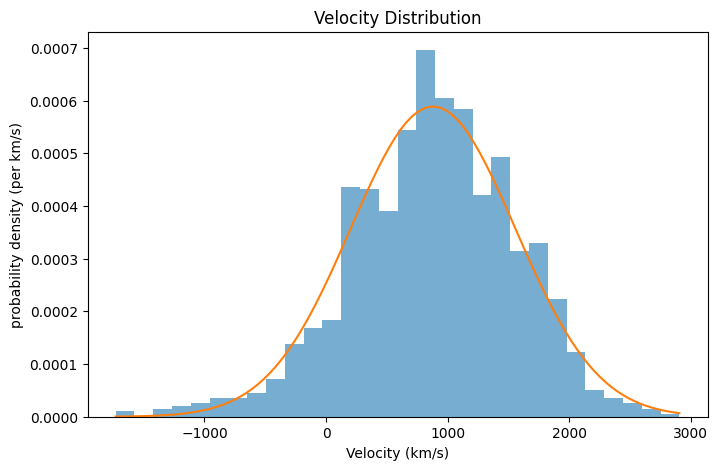

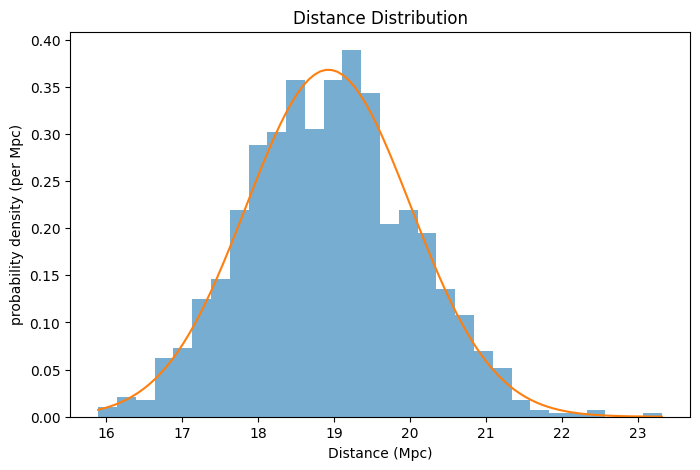

Estimated H = 46.47 ± 35.90 km/s/Mpc
Accepted H0 ≈ 73.5 km/s/Mpc
Difference = -27.03 km/s/Mpc
% error = 36.77 %


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

d1 = pd.read_csv('galaxy.csv')
d3 = pd.read_csv('cepheid.csv')

#radial velocity in km/s
W_obs = d1["Observed Wavelength of H-alpha"]
W_rest = 6562.8 #Å
c = 299792.458 #km/s
z = (W_obs - W_rest)/W_rest
v = c*z #km/s
d1['radial velocity (km/s)'] = v

#Galaxy/Cepheid distance in parsec
m = d3['Apparent Magnitude']
p = d3['Period']
logp = np.log10(p)
A = -1.826
B = 0.257
M = A * logp + B
distance_pc = 10 ** ((m - M + 5) / 5) #pc
d3['distance in parsec'] = distance_pc

#final galaxy distances in Mpc
final_distances = {}
for g in d3['Galaxy_ID'].unique():
    d_vals = d3[d3['Galaxy_ID'] == g]['distance in parsec']

    median = np.median(d_vals)
    std = np.std(d_vals)
    clean = d_vals[(d_vals > median - 2*std) & (d_vals < median + 2*std)]
    if len(clean) > 0:
      final_distances[g] = clean.mean() / 1e6#Mpc

distance_df = pd.DataFrame(list(final_distances.items()), columns=['Galaxy_ID', 'distance_Mpc'])
merged = d1.merge(distance_df, left_on='Name', right_on='Galaxy_ID', how='inner')

#Gaussian fit (velocity)
v_data = merged['radial velocity (km/s)']
mu_v, sigma_v = norm.fit(v_data)

plt.figure(figsize=(8,5))
plt.hist(v_data, bins=30, density=True, alpha=0.6)
x = np.linspace(min(v_data), max(v_data), 100)
plt.plot(x, norm.pdf(x, mu_v, sigma_v))
plt.xlabel("Velocity (km/s)")
plt.ylabel("probability density (per km/s)")
plt.title("Velocity Distribution")
plt.show()

#Gaussian fit (distance)
d_data = merged['distance_Mpc']
d_data = d_data[d_data > 15]  #Filtering obvious foreground galaxies (based on original results)
mu_d, sigma_d = norm.fit(d_data)

plt.figure(figsize=(8,5))
plt.hist(d_data, bins=30, density=True, alpha=0.6)
x = np.linspace(min(d_data), max(d_data), 100)
plt.plot(x, norm.pdf(x, mu_d, sigma_d))
plt.xlabel("Distance (Mpc)")
plt.ylabel("probability density (per Mpc)")
plt.title("Distance Distribution")
plt.show()

#Hubble's constant
H = mu_v / mu_d
delta_H = H * np.sqrt((sigma_v/mu_v)**2 + (sigma_d/mu_d)**2)

#Comparison with accepted value
H0_accepted = 73.50 #km/s/Mpc

print(f"Estimated H = {H:.2f} ± {delta_H:.2f} km/s/Mpc")
print(f"Accepted H0 ≈ {H0_accepted} km/s/Mpc")

difference = H - H0_accepted
print(f"Difference = {difference:.2f} km/s/Mpc")

percent_error = np.abs(difference / H0_accepted * 100)
print(f"% error = {percent_error:.2f} %")

#Estimation of Hubble's Constant using Radial Velocities and Distance to Galaxies
<p align="justify">The velocity distribution of galaxies exhibits a near-Gaussian profile centered around a mean value of approximately ~900 km/s, with a substantial spread indicating a velocity dispersion of a few hundred km/s. This is characteristic of galaxies within a gravitationally bound cluster, where random motions contribute significantly to the observed radial velocities. The symmetry of the distribution suggests that the system is approximately virialized, and the Gaussian fit provides a reasonable estimate of the mean cluster velocity and its dispersion.</P>

<p align="justify">In contrast, the distance distribution, after filtering, shows a well-defined peak around ~18-20 Mpc, corresponding to the cluster distance. Although the distribution is closer to Gaussian than before filtering, slight asymmetries and residual scatter are still present. These deviations arise due to uncertainties in Cepheid-based distance estimates, as well as contamination from foreground and background objects along the line of sight. Nevertheless, the dominant peak confirms that the majority of the galaxies belong to a single cluster at a consistent distance.</p>

<p align="justify">Using the mean values obtained from Gaussian fits, the Hubble constant was estimated as H = 46.47 ± 35.90 km/s/Mpc which is lower than the locally accepted value of H₀ ≈ 73.5 ± 0.81 km/s/Mpc. However, due to the large uncertainty, the result remains consistent with the accepted value within error margins.</p>

<p align="justify">The underestimation of H can be attributed to several physical and observational factors. First, the analysis is performed at relatively small distances ~20Mpc where peculiar velocities of galaxies—typically on the order of 300-500 km/s are comparable to the Hubble expansion velocity. As a result, the observed radial velocities deviate significantly from the pure cosmological recession velocity. Second, the galaxy cluster is a gravitationally bound system and does not strictly follow the linear Hubble flow, further distorting the velocity-distance relation. Additionally, residual contamination and scatter in the Cepheid distance measurements contribute to the large uncertainty in the final result.</p>

<p align="justify">A similar source of systematic deviation was observed earlier in the calibration of the Period-Luminosity relation, where the intercept β did not match the expected theoretical value (typically around ~-4). This discrepancy arises due to limitations in the dataset, including observational noise, lack of band-specific calibration (e.g., Gaia photometric system vs standard V/I bands), and the absence of extinction corrections. These factors shift the zero-point of the relation, thereby affecting the derived absolute magnitudes and, consequently, the distance estimates.</p>

<p align="justify">Overall, the analysis demonstrates that while the general trends predicted by the Hubble law and Cepheid Period-Luminosity relation are successfully recovered, precise cosmological measurements require larger distance scales, better-calibrated datasets, and careful treatment of systematic uncertainties.</p>

#Dark Matter
<p align="justify">In this section, the total mass of the galaxy cluster is estimated using the Virial Theorem, which relates the kinetic energy of galaxies within a gravitationally bound system to its total gravitational mass. The velocity dispersion obtained from the radial velocity distribution is used as a measure of the internal kinetic energy, while the cluster size provides a characteristic spatial scale. This allows for an estimate of the total mass of the cluster, including both visible and dark matter components.</P>

<p align="justify">To estimate the visible (luminous) mass, the Mass-Luminosity relation is employed by scaling galaxy luminosities relative to that of the Milky Way. Using the known absolute magnitude and mass of the Milky Way as a reference, the luminosities of cluster galaxies are converted into stellar mass estimates. The total visible mass is then obtained by summing contributions from individual galaxies.</p>

<p align="justify">Finally, the fraction of dark matter in the cluster is determined by comparing the visible mass to the total mass derived from the Virial Theorem. Any excess mass beyond the luminous component is attributed to dark matter, highlighting its dominant role in the mass budget of galaxy clusters.</p>

In [9]:
import numpy as np
import pandas as pd

d1 = pd.read_csv('galaxy.csv')
d3 = pd.read_csv('cepheid.csv')

#radial velocity in km/s
W_obs = d1["Observed Wavelength of H-alpha"]
W_rest = 6562.8 #Å
c = 299792.458 #km/s
z = (W_obs - W_rest)/W_rest
v = c*z #km/s
d1['radial velocity (km/s)'] = v

#Galaxy/Cepheid distance in parsec
m = d3['Apparent Magnitude']
p = d3['Period']
logp = np.log10(p)
A = -1.826
B = 0.257
M = A * logp + B
distance_pc = 10 ** ((m - M + 5) / 5) #pc
d3['distance in parsec'] = distance_pc

#final galaxy distances in Mpc
final_distances = {}
for g in d3['Galaxy_ID'].unique():
    d_vals = d3[d3['Galaxy_ID'] == g]['distance in parsec']

    median = np.median(d_vals)
    std = np.std(d_vals)
    clean = d_vals[(d_vals > median - 2*std) & (d_vals < median + 2*std)]
    if len(clean) > 0:
      final_distances[g] = clean.mean() / 1e6 #Mpc

distance_df = pd.DataFrame(list(final_distances.items()), columns=['Galaxy_ID', 'distance_Mpc'])
merged = d1.merge(distance_df, left_on='Name', right_on='Galaxy_ID', how='inner')

#Total Mass (Virial Theorem)
v_data = merged['radial velocity (km/s)']
v_mean = np.mean(v_data)
sigma_v = np.std(v_data)

R = 1.68 / 2 #cluster radius in Mpc
R_m = R * 3.086e22 #Mpc → meters
sigma_m = sigma_v * 1000 #km/s → m/s
G = 6.674e-11 #Nm²/kg²
M0 = 1.989e30 #Solar Mass in kg

# virial mass
M_total = (3 * sigma_m**2 * R_m) / G #kg
M_total_solar = M_total / M0 #in solar masses
print(f"Total Mass (Virial) = {M_total_solar:.2e} M☉")

#Absolute Magnitude
m_gal = merged['Apparent Mag']
d_pc = merged['distance_Mpc'] * 1e6
M_gal = m_gal - 5*np.log10(d_pc) + 5
merged['Absolute Magnitude'] = M_gal

#visible mass
M_gal = merged['Absolute Magnitude']
M_MW = -21 #milky way galaxy absolute magntiude
MASS_MW = 2e11  #milky way galaxy mass in solar masses
L_ratio = 10**(-0.4 * (M_gal - M_MW)) #luminosity scaling
M_visible_each = L_ratio * MASS_MW #mass of each galaxy
M_visible_total = np.sum(M_visible_each) #total visible mass
print(f"Visible (Baryonic) Matter = {M_visible_total:.2e} M☉")

#dark matter
f_DM = 1 - (M_visible_total / M_total_solar)
M_dark_total = M_total_solar - M_visible_total
print(f"Dark (non-lumionous) Matter = {M_dark_total:.2e} M☉")
print(f"Dark Matter Fraction = {f_DM:.2f}")

Total Mass (Virial) = 2.69e+14 M☉
Visible (Baryonic) Matter = 3.48e+13 M☉
Dark (non-lumionous) Matter = 2.34e+14 M☉
Dark Matter Fraction = 0.87


#Estimation of Dark Matter using Virial Theorem and Mass-Luminosity Relation
<p align="justify">The total mass of the galaxy cluster was estimated using the Virial Theorem, yielding a value of M_total = 2.69*10¹⁴ M☉. This represents the gravitational mass required to account for the observed velocity dispersion of galaxies within the cluster. The visible mass, derived from galaxy luminosities using the Mass-Luminosity relation scaled to the Milky Way, was found to be M_visible = 3.48*10¹³ M☉</p>

<p align="justify">So, the amount of dark matter in this particular galaxy cluster is M_dark = 2.34*10¹⁴ M☉. This indicates that approximately 87% of the total mass of the cluster is not directly observable and is attributed to dark matter.</p>

<p align="justify">The large discrepancy between the total mass and the visible mass highlights the dominant role of dark matter in galaxy clusters. While luminous matter accounts for only a small fraction of the mass, the gravitational dynamics, captured through the Virial Theorem, reveal a much larger mass component that does not emit electromagnetic radiation.</p>

<p align="justify">This result is consistent with modern astrophysical observations, which show that galaxy clusters are predominantly composed of dark matter, typically contributing about 80-90% of the total mass. The presence of such a large dark matter component is essential to explain the high velocity dispersion of galaxies and the overall stability of the cluster.</p>
